# 4. Language across repeat guest appearances

Someone with a book, a startup, or a cause goes on the podcast circuit: five
shows in three weeks, the same story each time. Or do they? Does a guest tailor
what they say to each host, or run the same material?

This is a question about **the same person across different contexts**, which is
exactly what a large multi-show corpus is for. It needs three things SPoRC makes
harder than you'd expect:

1. Guests who appear on **more than one** podcast.
2. Confidence that they **actually spoke** there.
3. A way to pull out **only their turns**.

Notebook 03 established that (2) is the hard part — `guest_predicted_names`
includes people who were merely *talked about*. We reuse that fix here.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
# Report the location relative to here, so the printed output does not embed
# whoever's home directory this happened to be built in.
print("sporc", sporc.__version__, "from",
      os.path.relpath(os.path.dirname(sporc.__file__)))


sporc 1.1.0 from ../../sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md. Kept
# relative so nothing machine-specific leaks into the logged path.
SUBSET = "../../subsets/tutorial"
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from ../../subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache ../../subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.01s  (514 podcasts, 4,072 episodes)


SPORCDataset(parquet, 514 podcasts, 4072 episodes)


## 4.1 Finding repeat guests

`guest_speaker_labels` maps a guest's name to the diarization label they were
assigned (`{"Jane Smith": "SPEAKER_01"}`). Non-empty means someone was actually
diarized as that person — and the label is also how we get their turns.


In [3]:
import json
from collections import defaultdict

def labels(e, attr):
    v = getattr(e, attr, None) or {}
    if isinstance(v, str):
        try:
            v = json.loads(v)
        except Exception:
            return {}
    return v if isinstance(v, dict) else {}

eps = [e for e in sporc.iterate_episodes() if e.has_turn_data]

# guest -> [(episode, speaker_label), ...]
appearances = defaultdict(list)
for e in eps:
    for name, label in labels(e, "guest_speaker_labels").items():
        appearances[name.strip().lower()].append((e, label))

# A repeat guest must span >=2 DISTINCT podcasts, not just 2 episodes of one
# show (a co-host would qualify on episodes alone).
repeat = {
    g: apps for g, apps in appearances.items()
    if len({e.podcast_title for e, _ in apps}) >= 2
}

print(f"guests with a real speaker label : {len(appearances):,}")
print(f"...on >=2 distinct podcasts      : {len(repeat):,}")
print()
for g, apps in sorted(repeat.items(), key=lambda kv: -len({e.podcast_title for e, _ in kv[1]}))[:12]:
    pods = {e.podcast_title for e, _ in apps}
    print(f"  {len(pods)} shows, {len(apps)} eps   {g}")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


guests with a real speaker label : 277
...on >=2 distinct podcasts      : 38

  13 shows, 13 eps   brian green
  6 shows, 6 eps   benjamin hardy
  4 shows, 5 eps   dave rubin
  4 shows, 4 eps   kwame christian
  3 shows, 3 eps   david ditchfield
  3 shows, 3 eps   antonio garrito
  3 shows, 3 eps   maggie reyes
  3 shows, 3 eps   chris ronsio
  3 shows, 3 eps   richard haas
  3 shows, 3 eps   michael ray
  3 shows, 3 eps   chris smith
  3 shows, 3 eps   lisa marie


## 4.2 Extracting one person's speech

The speaker label is per-episode: `SPEAKER_01` in one episode has nothing to do
with `SPEAKER_01` in another. So we look up the label per appearance and filter
that episode's turns to it.


In [4]:
import pandas as pd

def guest_turns(e, label):
    """Turns spoken by `label` in episode `e`."""
    return [t for t in e.turns if label in (t.speaker or [])]

rows = []
for g, apps in repeat.items():
    for e, label in apps:
        turns = guest_turns(e, label)
        if not turns:
            continue
        text = " ".join(t.text for t in turns)
        rows.append({
            # podcast_id/episode_id are the safe keys; the titles are for
            # reading. Counting distinct shows per guest below is the headline
            # number, so it groups on the id rather than the title.
            "guest": g, "podcast_id": e.podcast_id, "episode_id": e.episode_id,
            "podcast": e.podcast_title, "episode": e.title,
            "date": e.episode_date, "n_turns": len(turns),
            "n_words": len(text.split()),
            "speaking_time": sum(t.duration for t in turns),
            "text": text,
        })

app = pd.DataFrame(rows)
# Enough words to characterise someone's language at all.
app = app[app.n_words >= 300]
# Count distinct shows by id: two different podcasts can carry the same title,
# and this "appeared on >= 2 shows" filter is the notebook's whole premise.
counts = app.groupby("guest")["podcast_id"].nunique()
app = app[app.guest.isin(counts[counts >= 2].index)]

print(f"usable appearances : {len(app)}")
print(f"guests             : {app.guest.nunique()}")
if len(app):
    print()
    print(app.groupby("guest").agg(shows=("podcast_id","nunique"),
                                   words=("n_words","sum")).sort_values(
                                       "shows", ascending=False).head(10).to_string())


usable appearances : 109
guests             : 38

                  shows   words
guest                          
brian green          13  173079
benjamin hardy        6   29121
kwame christian       4   20534
dave rubin            4   27417
arlen hamilton        3    6258
antonio garrito       3   16451
eric adams            3    8856
david ditchfield      3   24048
maggie reyes          3   11856
lisa marie            3   11398


## 4.3 Phrase overlap across appearances

The test: is a guest's speech on show A more similar to **their own** speech on
show B than to a **different guest's** speech?

If people run the same material, within-guest similarity should exceed
between-guest similarity. If they tailor to each host, the gap should be small.

TF-IDF cosine is a crude similarity, but it's the right crudeness here — it keys
on shared distinctive vocabulary, which is what "the same anecdote" looks like.


In [5]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import itertools

if app.guest.nunique() >= 2:
    vec = TfidfVectorizer(stop_words="english", min_df=2, max_df=0.8,
                          sublinear_tf=True)
    X = vec.fit_transform(app.text)
    S = cosine_similarity(X)

    within, between = [], []
    guests = app.guest.values
    pods = app.podcast.values
    for i, j in itertools.combinations(range(len(app)), 2):
        if guests[i] == guests[j]:
            if pods[i] != pods[j]:        # same person, different shows
                within.append(S[i, j])
        else:
            between.append(S[i, j])

    print(f"within-guest, cross-show pairs : {len(within)}")
    print(f"between-guest pairs            : {len(between)}")
    if within and between:
        print(f"\nmean within-guest similarity  : {np.mean(within):.3f}")
        print(f"mean between-guest similarity : {np.mean(between):.3f}")
        print(f"ratio                         : {np.mean(within)/np.mean(between):.2f}x")
        from scipy import stats
        u, p = stats.mannwhitneyu(within, between, alternative="greater")
        print(f"\nMann-Whitney U (within > between): U={u:.0f}, p={p:.2e}")
else:
    within = between = []
    print("Not enough repeat guests in this subset for the comparison.")


within-guest, cross-show pairs : 166
between-guest pairs            : 5717

mean within-guest similarity  : 0.540
mean between-guest similarity : 0.109
ratio                         : 4.94x

Mann-Whitney U (within > between): U=884675, p=6.53e-81


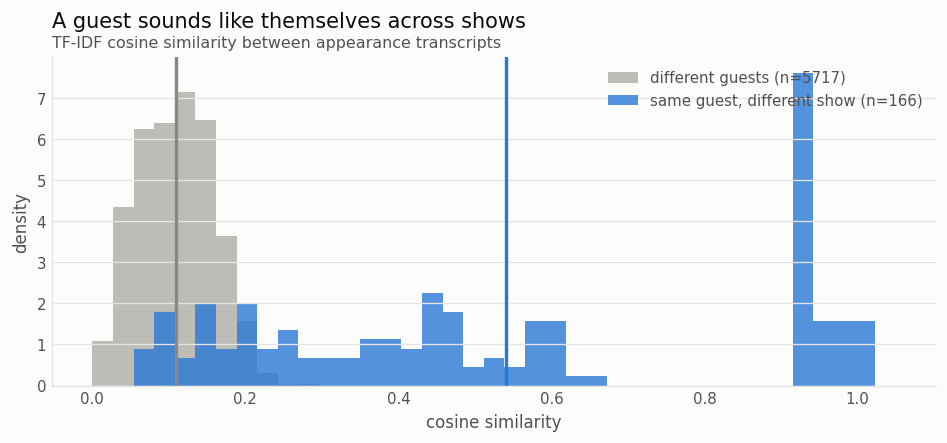

In [6]:
import matplotlib.pyplot as plt

if within and between:
    fig, ax = plt.subplots(figsize=(8, 3.8))
    bins = np.linspace(0, max(max(within), max(between)) * 1.05, 40)
    ax.hist(between, bins=bins, color=INK_MUTED, alpha=0.55,
            label=f"different guests (n={len(between)})", density=True)
    ax.hist(within, bins=bins, color=PALETTE[0], alpha=0.8,
            label=f"same guest, different show (n={len(within)})", density=True)
    ax.axvline(np.mean(between), color=INK_MUTED, linewidth=2)
    ax.axvline(np.mean(within), color=PALETTE[0], linewidth=2)
    ax.legend(loc="upper right")
    finish(ax, title="A guest sounds like themselves across shows",
           subtitle="TF-IDF cosine similarity between appearance transcripts",
           xlabel="cosine similarity", ylabel="density")
    plt.show()


## 4.4 The reused phrases

Similarity is an aggregate. The concrete version: which *exact* phrases does a
guest use on more than one show? Long shared n-grams are the fingerprint of
rehearsed material — a stump speech, a book anecdote, a founding story.


In [7]:
import re
from collections import Counter

def ngrams(text, n=7):
    words = re.findall(r"[a-z']+", text.lower())
    return {" ".join(words[i:i+n]) for i in range(len(words) - n + 1)}

if len(app):
    found = []
    for g, sub in app.groupby("guest"):
        if sub.podcast_id.nunique() < 2:
            continue
        per_show = {}
        for pod, s2 in sub.groupby("podcast"):
            per_show[pod] = ngrams(" ".join(s2.text))
        shows = list(per_show)
        for a, b in itertools.combinations(shows, 2):
            shared = per_show[a] & per_show[b]
            for phrase in shared:
                found.append({"guest": g, "show_a": a, "show_b": b,
                              "phrase": phrase})

    rep = pd.DataFrame(found)
    print(f"7-grams repeated across two different shows: {len(rep)}")
    if len(rep):
        print()
        for g, sub in list(rep.groupby("guest"))[:5]:
            print(f"{g} — {len(sub)} repeated phrases")
            for p in sub.phrase.head(4):
                print(f'   "{p}"')
            print()


7-grams repeated across two different shows: 626396

adam anks — 2 repeated phrases
   "next monday and the monday after that"
   "monday next monday and the monday after"

alvin ng — 1098 repeated phrases
   "didn't hesitate and that's how i came"
   "virtually in heaven for the first eight"
   "that i certainly thank you rachel can"
   "if you have no symptoms if you"

antonio garrito — 13 repeated phrases
   "goes into the flight simulator what they"
   "that the world smells of paint because"
   "she must think that the world smells"
   "think that the world smells of paint"

arlen hamilton — 3 repeated phrases
   "how to turn being underestimated into your"
   "to turn being underestimated into your greatest"
   "turn being underestimated into your greatest advantage"

benjamin hardy — 59 repeated phrases
   "because at the end of the day"
   "what these tests do is they give"
   "future self is going to be a"
   "that but one of the things that"



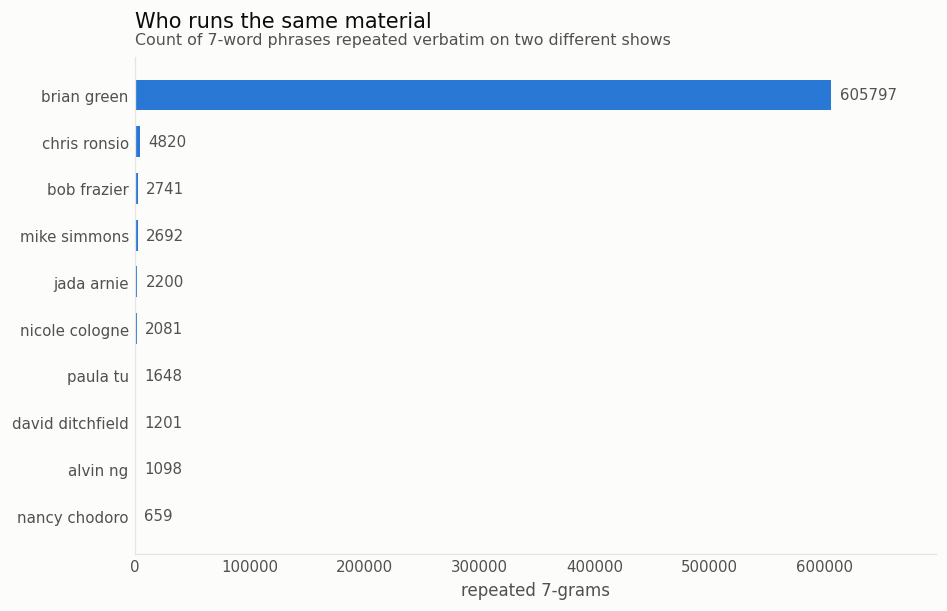

In [8]:
if len(app) and "rep" in dir() and len(rep):
    per_guest = (rep.groupby("guest").size().sort_values(ascending=False).head(10))
    fig, ax = plt.subplots(figsize=(8, max(2.2, 0.4*len(per_guest)+1.2)))
    y = np.arange(len(per_guest))
    ax.barh(y, per_guest.values[::-1], color=PALETTE[0], height=0.66)
    ax.set_yticks(y); ax.set_yticklabels([g[:30] for g in per_guest.index[::-1]])
    ax.grid(False, axis="y")
    for i, v in enumerate(per_guest.values[::-1]):
        ax.annotate(str(v), (v, i), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=9, color=INK_SECONDARY)
    ax.set_xlim(0, per_guest.max() * 1.15)
    finish(ax, title="Who runs the same material",
           subtitle="Count of 7-word phrases repeated verbatim on two different shows",
           xlabel="repeated 7-grams")
    plt.show()


## 4.5 Caveats

* **This is a lower bound on repeat guests.** Only diarized episodes have turns
  (~65%), and the guest must have been both diarized *and* correctly named. A
  guest who appeared on five shows may show up here on two.
* **Names are not resolved.** "Dr. Jane Smith" and "Jane Smith" are different
  people to this code. Cross-show matching therefore misses appearances, and
  common names ("chris smith") may merge two different humans — check the ones
  you report.
* **Diarization errors leak.** If the label is wrong for part of an episode, the
  guest's "speech" contains the host's words.
* **Two months.** A guest's tour has to fall inside May–June 2020 to be visible.
* **Similarity is topical, not stylistic.** TF-IDF cosine will call two
  appearances similar because they're about the same *subject*, which for a book
  tour is guaranteed. The repeated-n-gram view is the stronger evidence: exact
  phrase reuse is hard to explain by topic alone.
